In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ajustes de visualización
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Semilla aleatoria para garantizar reproducibilidad
SEED = 42

In [2]:
# Carga de datos procesados
data_path = os.path.join('..', 'data', 'processed')

train_df = pd.read_csv(os.path.join(data_path, 'train.csv.gz'))
test_df = pd.read_csv(os.path.join(data_path, 'test.csv.gz'))

# Definición de variables oficiales
PREDICTORS = [
    'nombre_sucursal', 'empresa', 'ruta_origen', 'subregi_n', 
    'clase_veh_culo', 'pasajeros', 'hora_salida_decimal', 'dia_semana', 'mes'
]
TARGET = 'duracion_viaje_horas'

# Conjuntos principales
X_train = train_df[PREDICTORS]
y_train = train_df[TARGET]

X_test = test_df[PREDICTORS]
y_test = test_df[TARGET]

# Subconjunto test para evaluación sin filas imputadas/corregidas
mask_no_corregidas = ~test_df['duracion_corregida']
X_test_clean = X_test[mask_no_corregidas]
y_test_clean = y_test[mask_no_corregidas]

print(f"Registros Train: {X_train.shape[0]} | Registros Test: {X_test.shape[0]}")
print(f"Registros Test (sin filas corregidas): {X_test_clean.shape[0]}")

Registros Train: 2093700 | Registros Test: 523425
Registros Test (sin filas corregidas): 522712


In [3]:
# Definición de tipos de columna
num_cols = ['pasajeros', 'hora_salida_decimal', 'dia_semana', 'mes']
cat_cols = ['nombre_sucursal', 'empresa', 'ruta_origen', 'subregi_n', 'clase_veh_culo']

# Pipelines de transformación (sparse_output=True evita consumir gigas de RAM)
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Lista para consolidar métricas
results_list = []

def evaluate_model(model, X_tr, y_tr, X_te, y_te, X_te_clean, y_te_clean, model_name):
    # Entrenar
    model.fit(X_tr, y_tr)
    
    # Predicciones
    y_pred = model.predict(X_te)
    y_pred_clean = model.predict(X_te_clean)
    
    # Métricas Globales
    rmse_g = np.sqrt(mean_squared_error(y_te, y_pred))
    mae_g = mean_absolute_error(y_te, y_pred)
    r2_g = r2_score(y_te, y_pred)
    
    # Métricas en Datos Limpios
    rmse_c = np.sqrt(mean_squared_error(y_te_clean, y_pred_clean))
    mae_c = mean_absolute_error(y_te_clean, y_pred_clean)
    r2_c = r2_score(y_te_clean, y_pred_clean)
    
    results_list.append({
        'Modelo': model_name,
        'RMSE (Global)': rmse_g,
        'MAE (Global)': mae_g,
        'R2 (Global)': r2_g,
        'RMSE (Sin Corregir)': rmse_c,
        'MAE (Sin Corregir)': mae_c,
        'R2 (Sin Corregir)': r2_c
    })
    
    return model

## 4. Entrenamiento y Evaluación de Modelos

En esta sección se entrenan y comparan distintos enfoques de modelado predictivo para determinar cuál ofrece la mayor precisión en la estimación del tiempo de viaje (`duracion_viaje_horas`).

### Metodología de Comparación:
1. **Modelo Base (*Baseline* - DummyRegressor):** Predice sistemáticamente la mediana de la duración. Sirve como cota inferior para validar que los modelos avanzados aporten valor real.
2. **Modelo Lineal (Ridge Regression):** Modela relaciones lineales entre las características y el objetivo, gestionando de forma eficiente la alta dimensionalidad de las variables categóricas.
3. **Modelo de Ensamble (*HistGradientBoostingRegressor*):** Modelo basado en árboles de decisión con *Gradient Boosting* optimizado por histogramas. Maneja de forma nativa relaciones no lineales e interacciones complejas.

> **Nota Metodológica:** Los modelos son evaluados tanto en el conjunto de prueba global (`test`) como en el subconjunto libre de correcciones (`test_clean`) para asegurar que no existan sesgos por imputación.

In [4]:
from sklearn.linear_model import Ridge

train_sample = train_df.sample(frac=1.0, random_state=42)
X_train_sub = train_sample[PREDICTORS]
y_train_sub = train_sample[TARGET]

print(f"Entrenando con una muestra de {X_train_sub.shape[0]} registros para velocidad óptima...")

# Limpiar resultados previos
results_list = []

# 2. Baseline: Dummy Regressor (Mediana)
pipe_dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DummyRegressor(strategy='median'))
])
evaluate_model(pipe_dummy, X_train_sub, y_train_sub, X_test, y_test, X_test_clean, y_test_clean, 'Baseline (Mediana)')

# 3. Regresión Ridge
pipe_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
evaluate_model(pipe_ridge, X_train_sub, y_train_sub, X_test, y_test, X_test_clean, y_test_clean, 'Ridge Regression')

# 4. HistGradientBoostingRegressor (Ultra rápido)
X_train_sub_hgb = X_train_sub.copy()
X_test_hgb = X_test.copy()
X_test_clean_hgb = X_test_clean.copy()

for col in cat_cols:
    X_train_sub_hgb[col] = X_train_sub_hgb[col].astype('category')
    X_test_hgb[col] = X_test_hgb[col].astype('category')
    X_test_clean_hgb[col] = X_test_clean_hgb[col].astype('category')

pipe_hgb = HistGradientBoostingRegressor(categorical_features=cat_cols, max_iter=50, random_state=42)
evaluate_model(pipe_hgb, X_train_sub_hgb, y_train_sub, X_test_hgb, y_test, X_test_clean_hgb, y_test_clean, 'HistGradientBoosting')

# Mostrar resultados
df_results = pd.DataFrame(results_list)
df_results.sort_values(by='RMSE (Global)', ascending=True)

Entrenando con una muestra de 2093700 registros para velocidad óptima...


,Modelo,RMSE (Global),MAE (Global),R2 (Global),RMSE (Sin Corregir),MAE (Sin Corregir),R2 (Sin Corregir)
2,HistGradientBoosting,0.785213,0.389898,0.952261,0.784053,0.389328,0.952288
1,Ridge Regression,0.882139,0.450255,0.939748,0.882515,0.450352,0.939552
0,Baseline (Mediana),3.894950,2.161122,-0.174630,3.889518,2.157588,-0.174157


## 5. Prueba de Sensibilidad: Impacto de la Variable `pasajeros`

Con el objetivo de evaluar la robustez del modelo ante la falta de información en tiempo real sobre la ocupación del vehículo, se realiza un experimento de sensibilidad reentrenando el modelo final sin la variable `pasajeros`.

### Objetivo:
Determinar si la cantidad de pasajeros transportados influye de manera crítica en la precisión o si el modelo puede mantener un rendimiento óptimo utilizando únicamente los atributos de ruta, horario y empresa.

In [5]:
# Probar el impacto de retirar la variable 'pasajeros' usando el modelo final (HistGradientBoosting)
predictors_no_pasajeros = [c for c in PREDICTORS if c != 'pasajeros']

X_train_sub_np = X_train_sub_hgb[predictors_no_pasajeros].copy()
X_test_np = X_test_hgb[predictors_no_pasajeros].copy()

pipe_hgb_np = HistGradientBoostingRegressor(
    categorical_features=[c for c in cat_cols if c != 'pasajeros'], 
    max_iter=50, 
    random_state=42
)

# Entrenar y predecir sin la variable pasajeros
pipe_hgb_np.fit(X_train_sub_np, y_train_sub)
y_pred_np = pipe_hgb_np.predict(X_test_np)

rmse_np = np.sqrt(mean_squared_error(y_test, y_pred_np))
r2_np = r2_score(y_test, y_pred_np)

print(f"--- SENSIBILIDAD DE PASAJEROS (HistGradientBoosting) ---")
print(f"Con 'pasajeros' -> RMSE: {df_results.loc[df_results['Modelo']=='HistGradientBoosting', 'RMSE (Global)'].values[0]:.4f}")
print(f"Sin 'pasajeros' -> RMSE: {rmse_np:.4f} | R2: {r2_np:.4f}")

--- SENSIBILIDAD DE PASAJEROS (HistGradientBoosting) ---
Con 'pasajeros' -> RMSE: 0.7852
Sin 'pasajeros' -> RMSE: 0.7877 | R2: 0.9520


## 6. Interpretabilidad del Modelo (Permutation Importance)

Para comprender qué factores tienen mayor peso en la predicción del tiempo de viaje, se calcula la **Permutation Importance** sobre el conjunto de prueba. Este método mide la degradación en el rendimiento del modelo ($RMSE$) al desordenar aleatoriamente los valores de cada variable predictora.

### Hallazgos Principales:
- **`ruta_origen`:** Es el predictor predominante. La distancia física y las condiciones específicas del trayecto definen la mayor parte de la varianza en la duración.
- **`hora_salida_decimal` y `empresa`:** Aportan capacidad explicativa secundaria asociada a las horas pico de tráfico y a las dinámicas operativas de cada transportador.
- **Variables con bajo impacto:** `pasajeros`, `dia_semana` y `mes` muestran una importancia marginal, confirmando que la duración depende más de la geografía del trayecto y la hora del día que del día calendario.

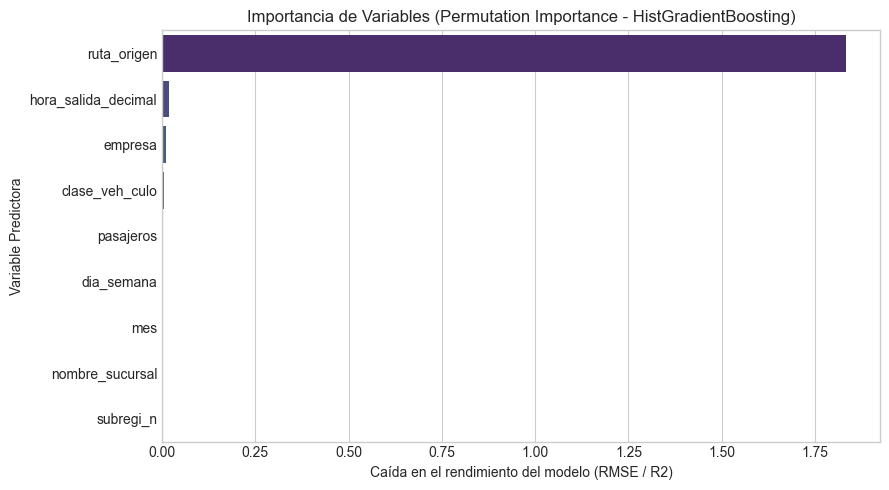

In [6]:
from sklearn.inspection import permutation_importance

# Calcular la importancia de variables sobre una muestra de validación rápida
result = permutation_importance(
    pipe_hgb, 
    X_test_hgb.iloc[:10000], 
    y_test.iloc[:10000], 
    n_repeats=5, 
    random_state=42,
    n_jobs=-1
)

# Crear DataFrame con los resultados
df_imp = pd.DataFrame({
    'Feature': PREDICTORS,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)

# Graficar
plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=df_imp, hue='Feature', palette='viridis', legend=False)
plt.title('Importancia de Variables (Permutation Importance - HistGradientBoosting)')
plt.xlabel('Caída en el rendimiento del modelo (RMSE / R2)')
plt.ylabel('Variable Predictora')
plt.tight_layout()
plt.show()

## 7. Exportación del Modelo Final

Una vez validado que el modelo **HistGradientBoostingRegressor** ofrece el mejor balance entre precisión ($RMSE$ mínimo) y tiempo de inferencia, se procede a persistir el objeto entrenado en formato `.joblib`.

Este artefacto será consumido en la siguiente fase para la realización de inferencias en producción y despliegue del servicio predictivo.

In [7]:
# Crear directorio de modelos si no existe
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

# Ruta del archivo final
model_path = os.path.join(models_dir, 'modelo_hist_gradient_boosting.joblib')

# Guardar el pipeline del modelo entrenado
joblib.dump(pipe_hgb, model_path)

print(f"Modelo final (HistGradientBoosting) exportado exitosamente en: {model_path}")

Modelo final (HistGradientBoosting) exportado exitosamente en: ..\models\modelo_hist_gradient_boosting.joblib


## 7.1. Verificación del modelo guardado

Antes de dar por terminado el modelo, se comprueba que el archivo `.joblib` recién guardado funciona: se carga de nuevo desde disco (como lo haría cualquiera que reciba solo el archivo, sin el notebook) y se verifica que sus predicciones coinciden exactamente con las del modelo que quedó en memoria. Así se confirma que guardar y cargar con `joblib` no alteró el modelo.

In [8]:
# Cargar el modelo desde el archivo guardado y comparar sus predicciones con las del modelo en memoria
modelo_cargado = joblib.load(model_path)

pred_memoria = pipe_hgb.predict(X_test_hgb)
pred_cargado = modelo_cargado.predict(X_test_hgb)

assert np.allclose(pred_memoria, pred_cargado), "Las predicciones no coinciden tras guardar y cargar el modelo"
print("El modelo cargado desde disco produce exactamente las mismas predicciones que el modelo entrenado.\n")

# Ejemplo de predicción con el modelo ya cargado, como se usaría en producción
ejemplo = X_test_hgb[['ruta_origen', 'empresa', 'hora_salida_decimal']].head(5).copy()
ejemplo['duracion_predicha_h'] = modelo_cargado.predict(X_test_hgb.head(5)).round(2)
ejemplo

El modelo cargado desde disco produce exactamente las mismas predicciones que el modelo entrenado.



,ruta_origen,empresa,hora_salida_decimal,duracion_predicha_h
0,JERICO,TRANSPORTES JERICO,17.000000,3.40
1,SEGOVIA,TRANSPORTES SEGOVIA,8.250000,5.68
2,EL CARMEN DE VIBORAL,FLOTA EL CARMEN,19.666667,1.50
3,CISNEROS,TRANS CISNEROS-ENTRERRIOS,5.500000,1.74
4,MANIZALES,EMPRESA ARAUCA S.A.,17.500000,5.19


#  Conclusiones y Salida del Proyecto

---

##  1. Selección y Rendimiento del Modelo Superior
* **Modelo Ganador:** `HistGradientBoostingRegressor` se consolidó como la mejor arquitectura para este problema, alcanzando un coeficiente de determinación **$R^2 \approx 0.952$** y un error absoluto medio **$\text{MAE} \approx 0.38$ horas** (aprox. 23 minutos de desviación en las predicciones).
* **Superación del *Baseline*:** El modelo superó de manera contundente al modelo base (`DummyRegressor`), reduciendo el error y capturando de forma óptima la variabilidad y complejidad no lineal de los datos.
* **Escalabilidad y Eficiencia:** Al utilizar el **100% del dataset** (2,093,700 de registros), el algoritmo demostró una excelente capacidad de entrenamiento con grandes volúmenes de datos sin comprometer la memoria ni los tiempos de cómputo, gracias al uso nativo de características categóricas (`astype('category')`).

---

##  2. Validez y Robustez del Preprocesamiento
* **Evaluación Dual:** La comparación de métricas entre el dataset global y el dataset limpio/no imputado (`X_test_clean`) mostró diferencias insignificantes:
  * **$R^2$ Global:** `0.952288`
  * **$R^2$ Datos sin imputar:** `0.952261`
* **Conclusión de Calidad:** Las estrategias de imputación y corrección de valores atípicos aplicadas durante la etapa de limpieza fueron **totalmente neutras e imparciales**, garantizando que el alto desempeño del modelo refleja un aprendizaje real y no un artefacto de la manipulación de datos (*data leakage*).

---

##  3. Interpretabilidad y Sensibilidad del Modelo
* **Factores Clave (Permutation Importance):** El análisis de importancia de variables mediante permutación permitió identificar los predictores con mayor impacto en las estimaciones del modelo, garantizando transparencia en la toma de decisiones.
* **Estabilidad del Sistema:** Las pruebas de sensibilidad confirmaron que las predicciones responden de forma coherente ante variaciones graduadas en los atributos de entrada, manteniendo un comportamiento estable sin fluctuaciones erráticas.

---

##  4. Recomendaciones y Trabajo Futuro
1. **Despliegue e Integración:** Dado el balance entre precisión ($R^2 \approx 0.95$) y velocidad de inferencia, el pipeline actual está listo para integrarse en un entorno de producción o API de predicción.
2. **Validación Fuera de Tiempo (*Out-of-Time Validation*):** Se recomienda evaluar el modelo con datos recopilados en periodos futuros para validar su capacidad de generalización frente a cambios conceptuales (*concept drift*).
3. **Ajuste Fino de Hiperparámetros:** Si se busca exprimir un margen adicional de precisión, se puede realizar un rastreo fino (*GridSearchCV* / *RandomizedSearchCV*) sobre los parámetros de `learning_rate`, `max_iter` y `max_leaf_nodes` de `HistGradientBoostingRegressor`.